# Curvas de Transferencia — EGOFET

Análisis de curvas $I_{DS}$ vs $V_{GS}$ a $V_{DS}$ constante.
De aquí extraemos: $V_{th}$, movilidad, $SS$, relación $I_{on}/I_{off}$.

In [ ]:
# === Paso 1: Setup: imports, rutas, listar archivos ===
import os
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Para hacer 'from src import ...', Python necesita que el project root
# este en sys.path. Jupyter no lo agrega solo, asi que lo añadimos a mano.
# Truco: subimos desde CWD hasta encontrar un directorio que contenga 'src'.
# Asi funciona sin importar desde donde se haya lanzado el kernel.

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]: # Va hacia atras hasta encontrar el root donde se encuentra el marker
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"No se encontro el project root con marcador '{marker}'. "
        f"Partiendo de: {cwd}"
    )

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# importamos librerias locales de src
from src.readers.keithley_dean import list_measurements, read_curve, read_all_curves, view_measurements
from src.readers import print_structure
from src.plotting import plot_transfer

data_folder = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:   {data_folder}")
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

Project root: /Users/David/Documents/academia/doctorado/egofets_poject
Data folder:   /Users/David/Documents/academia/doctorado/egofets_poject/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.2.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5
  2026-07-08_test.hdf5
  2026-07-23 TMTES PS Phototransistor v3.hdf5


In [2]:
# === Paso 2: Abrir HDF5 y listar SOLO los grupos top-level (mediciones) ===
# Cada grupo top-level es una medicion distinta (transfer, output, o stability)

hdf5_name = "2026-06-30_test3.hdf5"
hdf5_path = os.path.join(data_folder, hdf5_name)

view_measurements(hdf5_path)

Archivo: 2026-06-30_test3.hdf5
Mediciones encontradas (21):

  010626_batch1_mta1_00                               mode=transfer    curves=2
  010626_batch1_mta1_01                               mode=output      curves=7
  010626_batch1_mta1_02                               mode=desconocido  curves=0
  010626_batch1_mta1_03                               mode=transfer    curves=2
  010626_batch1_mta1_04                               mode=output      curves=7
  010626_batch1_mta1_05                               mode=desconocido  curves=0
  010626_batch2_mta1_00                               mode=transfer    curves=2
  010626_batch2_mta1_01                               mode=output      curves=7
  010626_batch2_mta1_02                               mode=transfer    curves=2
  010626_batch2_mta1_03                               mode=output      curves=7
  010626_batch3_mta1_00                               mode=transfer    curves=2
  010626_batch3_mta1_01                               mod

'  010626_batch1_mta1_00                               mode=transfer    curves=2\n  010626_batch1_mta1_01                               mode=output      curves=7\n  010626_batch1_mta1_02                               mode=desconocido  curves=0\n  010626_batch1_mta1_03                               mode=transfer    curves=2\n  010626_batch1_mta1_04                               mode=output      curves=7\n  010626_batch1_mta1_05                               mode=desconocido  curves=0\n  010626_batch2_mta1_00                               mode=transfer    curves=2\n  010626_batch2_mta1_01                               mode=output      curves=7\n  010626_batch2_mta1_02                               mode=transfer    curves=2\n  010626_batch2_mta1_03                               mode=output      curves=7\n  010626_batch3_mta1_00                               mode=transfer    curves=2\n  010626_batch3_mta1_01                               mode=output      curves=7\n  010626_batch3_mta1_02  

In [3]:
# === Paso 3: Leer una curva transfer ===
# Probamos función para extraer datos de transfer

measurement_name = "010626_batch1_mta1_00"
curve_name = "curve_000"

v_gs, i_ds = read_curve(hdf5_path, measurement_name, curve_name)

dic_data = {
    "gate voltaje": v_gs,
    "current drain": i_ds
            }

df = pd.DataFrame(dic_data)
print(df) # Esto solo como ejemplo de que se pueden obtener estos datos para su graficacion

# fig, ax = plt.subplots()

# ax.plot(df["gate voltaje"], df["current drain"], label="curve 000")
# ax.set_title("Transfer curve - " + measurement_name)

#plt.show()

    gate voltaje  current drain
0       0.400188  -1.295800e-09
1       0.390027  -4.982950e-10
2       0.380208   6.556510e-11
3       0.370028  -6.914140e-11
4       0.360167   2.741810e-11
..           ...            ...
76     -0.359747  -1.466710e-06
77     -0.369604  -1.540820e-06
78     -0.379794  -1.615940e-06
79     -0.389667  -1.691160e-06
80     -0.399516  -1.770060e-06

[81 rows x 2 columns]


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Transfer — 010626_batch1_mta1_00'}, xlabel='$V_{GS}$ (V)', ylabel='$I_{DS}$ (A)'>)

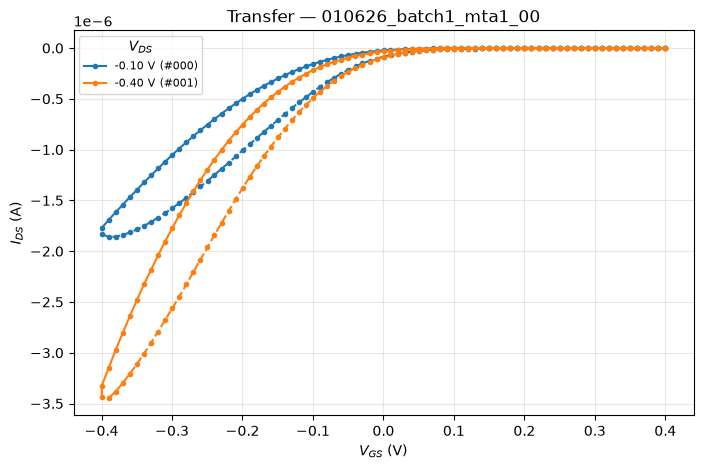

In [4]:
# === Paso 4: graficar datos con funciones de src ===
measurement_name = "010626_batch1_mta1_00"

plot_transfer(hdf5_path, measurement_name)


['010626_batch1_mta1_00', '010626_batch1_mta1_03', '010626_batch2_mta1_00', '010626_batch2_mta1_02', '010626_batch3_mta1_00', '010626_batch3_mta1_03', '010626_batch4_mta1_00', '010626_batch4_mta1_02', '010626_batch4_mta1_03']


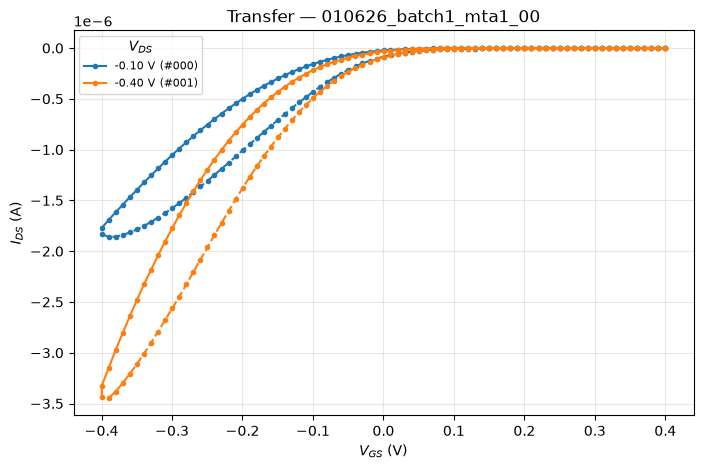

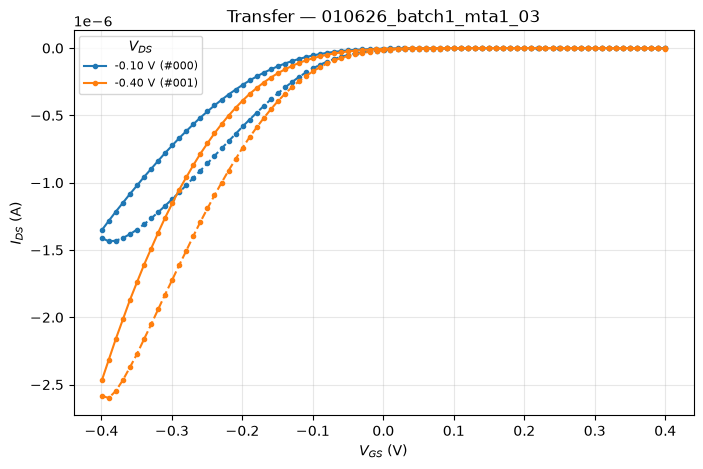

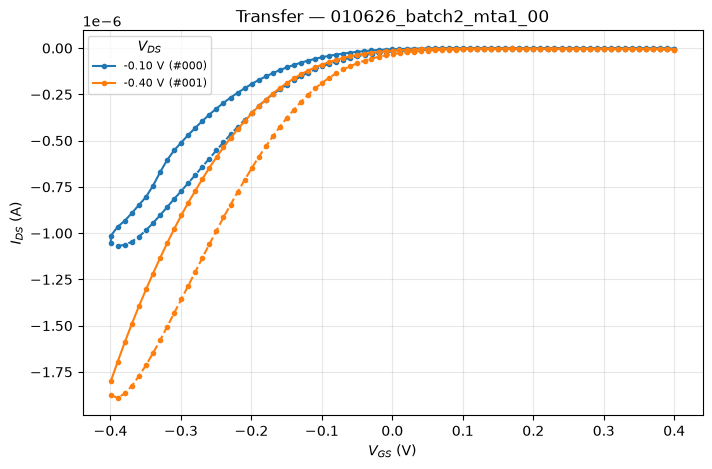

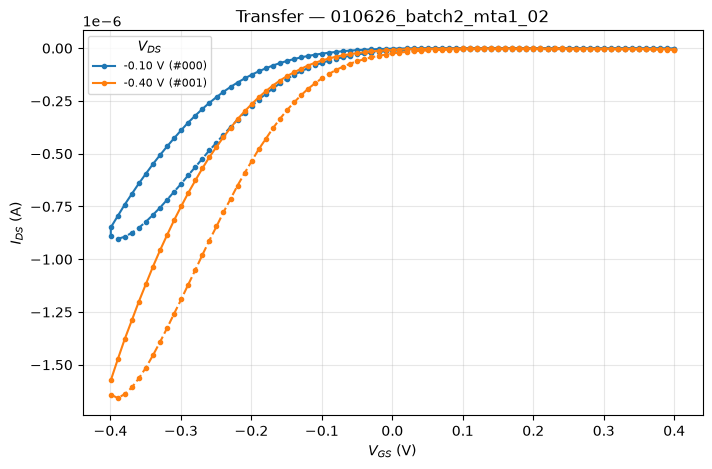

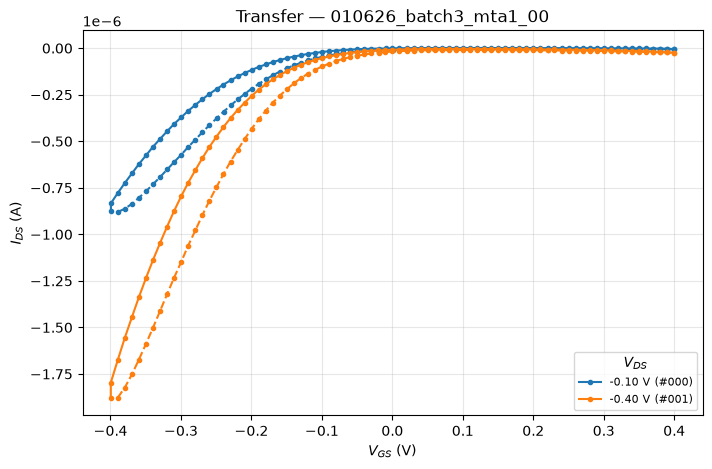

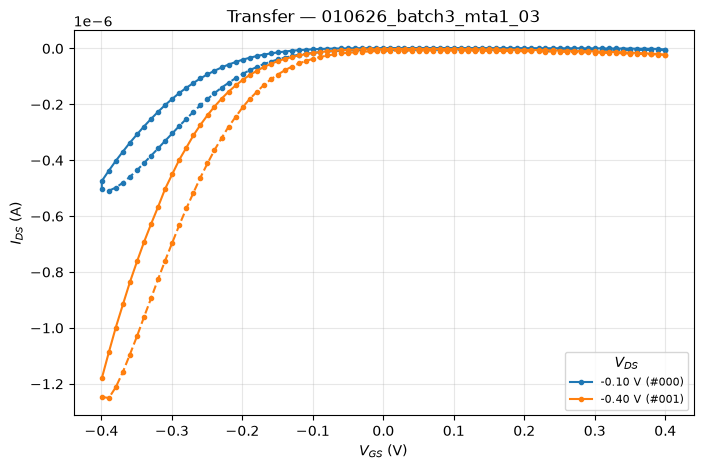

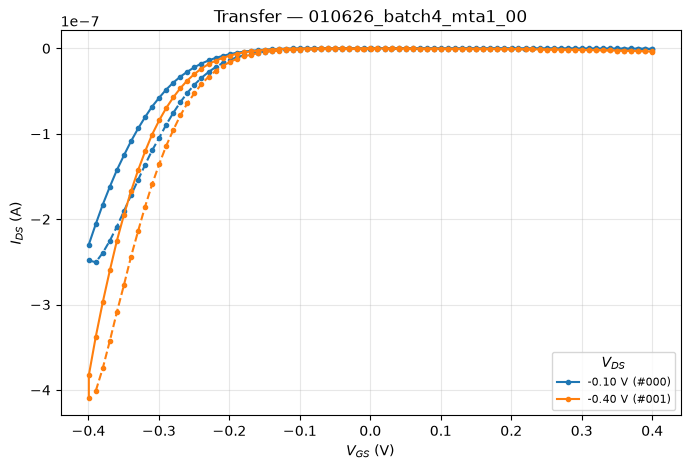

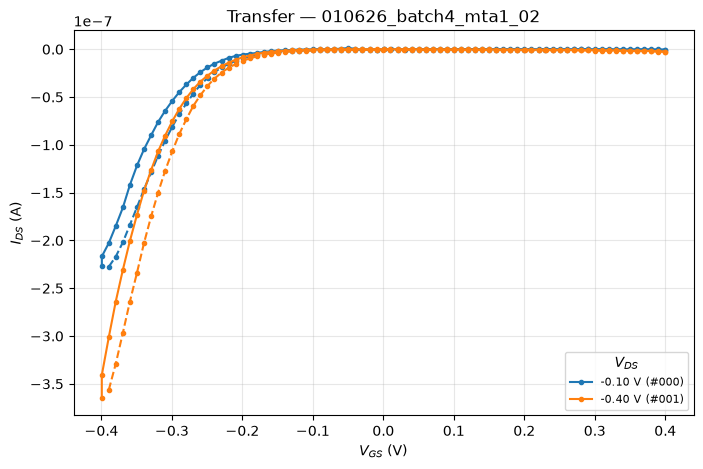

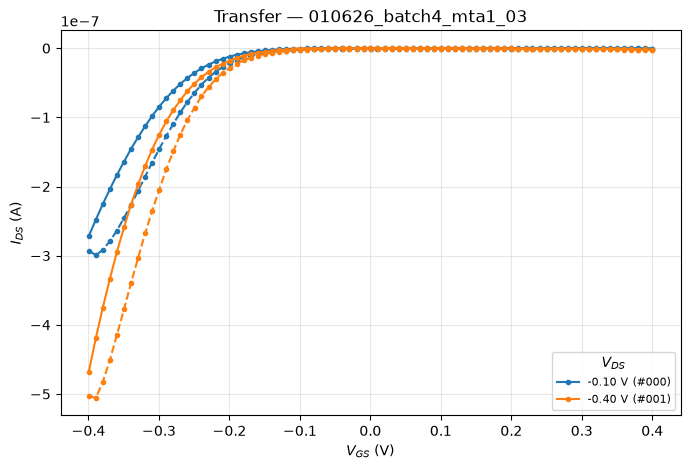

In [5]:
# === Paso 5: graficar una lista con los batch a observar ===
measurement_list_dic = list_measurements(hdf5_path)

measurement_list_names = [measurement["name"] for measurement in measurement_list_dic if measurement["mode"] == "transfer"]
print(measurement_list_names)

measurements_name_issue = []

for measurement_name in measurement_list_names:
    try:
        plot_transfer(hdf5_path, measurement_name)
    except TypeError:
        print(f"Couldn't plot {measurement_name} due to a TypeError")
        measurements_name_issue.append(measurement_name)
        continue

## Extracción de parámetros

### $V_{th}$ — $\sqrt{I_{DS}}$ (saturación)

In [6]:
# Realizar extracción de saturación para una sola muestra
print("Analizando muestra: " + measurement_name)

curves = read_all_curves(hdf5_path, measurement_name)

i_max = max(range(len(curves)), key=lambda i: abs(curves[i]['v_ds']))
curve = curves[i_max]
v_gs, i_ds, v_ds = curve['v_gs'], curve['i_ds'], curve['v_ds']
print(f"Usando V_DS = {v_ds} V\ncurve={curve.keys()}") # Es el transfer más alto que asegura el régimen saturado para obtener el V_th


Analizando muestra: 010626_batch4_mta1_03
Usando V_DS = -0.4 V
curve=dict_keys(['v_gs', 'i_ds', 'v_ds', 'curve_name'])


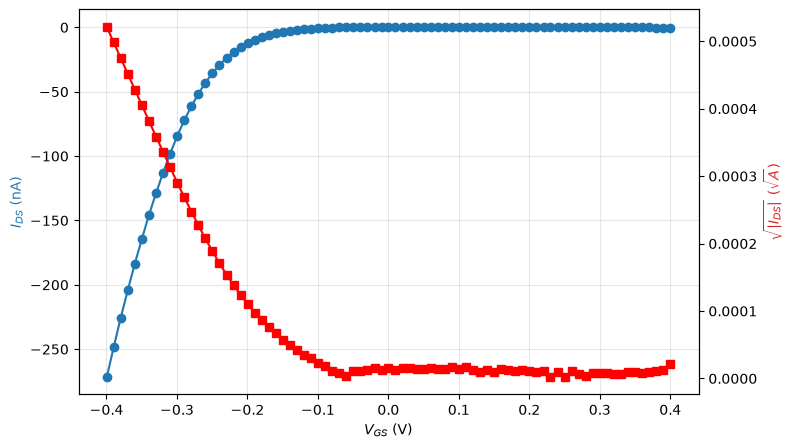

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
v_gs_fwd, i_ds_fwd = read_curve(hdf5_path, measurement_name, fwd_only=True)
# plot 1: I_DS vs V_GS (la transfer normal)
ax.plot(v_gs_fwd, i_ds_fwd * 1e9, 'o-', label=r'$I_{DS}$')
# plot 2: sqrt(|I_DS|) vs V_GS, mismo eje x
ax2 = ax.twinx()
sqrt_ids = np.sqrt(np.abs(i_ds_fwd))
ax2.plot(v_gs_fwd, sqrt_ids, 'rs-', label=r'$\sqrt{|I_{DS}|}$')
ax.set_xlabel(r'$V_{GS}$ (V)')
ax.set_ylabel(r'$I_{DS}$ (nA)', color='C0')
ax2.set_ylabel(r'$\sqrt{|I_{DS}|}$ ($\sqrt{A}$)', color='C3')
ax.grid(True, alpha=0.3)


### $V_{th}$ — Método lineal

De forma "automática" vamos a replicar encontrar la regresión lineal con mejor ajuste con la segunda derivada de la función original.

In [9]:
# Activa el backend interactivo de matplotlib para que los sliders funcionen
# (necesita tener instalado ipympl: pip install ipympl)
# %matplotlib widget   # descomentar si tienes ipympl instalado

from matplotlib.widgets import Slider
from scipy.stats import linregress

# ====================================================================
# DATOS: usamos los que ya cargamos en la celda 7
#   x = V_GS del forward sweep
#   y = sqrt(|I_DS|), que es lo que se lineariza en saturacion
# ====================================================================
x = v_gs_fwd
y = sqrt_ids

# ====================================================================
# VENTANA INICIAL: estos valores los elegiste a ojo en la celda 8.
# Son el punto de partida del slider; los moveras interactivamente.
# ====================================================================
v_min_init = -0.30
v_max_init = -0.12

# ====================================================================
# FIGURA: dos subplots apilados
#   - Arriba: datos + ajuste lineal dentro de la ventana
#   - Abajo:  segunda derivada numerica (referencia visual)
# ====================================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}  # el de arriba 3x mas alto
)
plt.subplots_adjust(bottom=0.25, hspace=0.3)  # espacio para los sliders

# ----- Subplot superior: datos y ajuste -----
line_data, = ax1.plot(x, y, 'rs-', ms=4, label=r'$\sqrt{|I_{DS}|}$')
line_fit,  = ax1.plot([], [], 'g--', lw=2, label='Ajuste lineal')
# Lineas verticales que muestran los extremos de la ventana (se actualizan con el slider)
line_vmin = ax1.axvline(v_min_init, color='gray', ls=':', lw=1)
line_vmax = ax1.axvline(v_max_init, color='gray', ls=':', lw=1)
ax1.set_ylabel(r'$\sqrt{|I_{DS}|}$ ($\sqrt{A}$)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Cuadro de texto con V_th y R^2 (se actualiza dentro de update)
text_results = ax1.text(
    0.02, 0.95, '', transform=ax1.transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.7)
)

# ----- Subplot inferior: segunda derivada numerica -----
# np.gradient calcula d(y)/d(x) numericamente.
# Lo aplicamos dos veces para obtener la segunda derivada.
# Donde d^2 ~= 0, la curva es mas lineal (esa es la region que queremos ajustar).
d2 = np.gradient(np.gradient(y, x), x)
ax2.plot(x, d2, 'b-', lw=1.5, label=r"$\frac{d^2\sqrt{|I_{DS}|}}{dV_{GS}^2}$")
ax2.axhline(0, color='k', lw=0.5, ls='--')
ax2.set_xlabel(r'$V_{GS}$ (V)')
ax2.set_ylabel(r'$d^2 y / dV_{GS}^2$')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# ====================================================================
# SLIDERS: controlan los extremos de la ventana de ajuste
# ====================================================================
# Posicion [izquierda, abajo, ancho, alto] en coords de la figura (0-1)
ax_vmin = plt.axes([0.15, 0.10, 0.7, 0.03])
ax_vmax = plt.axes([0.15, 0.05, 0.7, 0.03])
slider_vmin = Slider(ax_vmin, r'$V_{min}$ (V)', float(x.min()), float(x.max()),
                     valinit=v_min_init)
slider_vmax = Slider(ax_vmax, r'$V_{max}$ (V)', float(x.min()), float(x.max()),
                     valinit=v_max_init)

# ====================================================================
# UPDATE: se ejecuta cada vez que se mueve un slider
# ====================================================================
def update(val):
    v_min = slider_vmin.val
    v_max = slider_vmax.val

    # Validaciones: ventana invalida (vacia o invertida)
    if v_min >= v_max:
        return
    mask = (x >= v_min) & (x <= v_max)
    if mask.sum() < 3:  # muy pocos puntos para ajustar
        return

    # Ajuste lineal (minimos cuadrados) en la ventana seleccionada
    x_win, y_win = x[mask], y[mask]
    slope, intercept, r_value, _, _ = linregress(x_win, y_win)

    # V_th: x-intercepto de la recta ajustada (donde y = 0)
    v_th = -intercept / slope

    # Actualizar las lineas del plot con el nuevo ajuste
    line_fit.set_data(x_win, slope * x_win + intercept)
    line_vmin.set_xdata([v_min])
    line_vmax.set_xdata([v_max])

    # Actualizar el cuadro de texto con los resultados
    text_results.set_text(
        f'$V_{{th}}$ = {v_th:.3f} V\n'
        f'$R^2$ = {r_value**2:.4f}\n'
        f'Puntos en ventana: {mask.sum()}'
    )

    # Redibujar la figura (draw_idle es mas eficiente que draw_reload)
    fig.canvas.draw_idle()

# Conectar los sliders a la funcion update
slider_vmin.on_changed(update)
slider_vmax.on_changed(update)

plt.show()


RuntimeError: 'ipympl' is not a recognised GUI loop or backend name

De forma manual, elegiremos la ventana de regresión según veamos el gráfico de transfer y $\sqrt{I_{DS}}$ cómo cambia de la sección plana a lineal.

/var/folders/_4/yq1f85w95_97_zvrgl2bh1p00000gp/T/ipykernel_98826/2401905359.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(v_gs_fwd[mask], intercept + slope * v_gs_fwd[mask], "r--", color="green", label="linear fit")


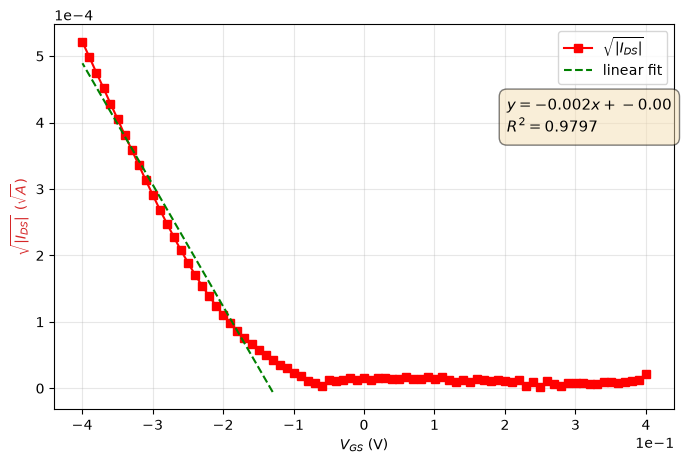

In [8]:
# Elegimos una ventana de ajsute
mask = (v_gs_fwd > -0.4) & (v_gs_fwd < -0.12)

# Aplicamos regresión lineal y extraemos valores
slope, intercept, r_value, _, _ = linregress(v_gs_fwd[mask], sqrt_ids[mask])

txt_fit_data = (f'$y = {slope:.3f}x + {intercept:.2f}$\n'
               f'$R^2 = {r_value**2:.4f}$')

# Ploteamos en el gráfico existente
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(v_gs_fwd, sqrt_ids, 'rs-', label=r'$\sqrt{|I_{DS}|}$')

ax.plot(v_gs_fwd[mask], intercept + slope * v_gs_fwd[mask], "r--", color="green", label="linear fit")

ax.text(0.73, 0.72, s=txt_fit_data, transform=ax.transAxes, fontsize=11, bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

ax.set_ylabel(r'$\sqrt{|I_{DS}|}$ ($\sqrt{A}$)', color='C3')
ax.set_xlabel(r'$V_{GS}$ (V)')
ax.axes.ticklabel_format(style="sci", scilimits=(-3,-4))
ax.legend()
ax.grid(True, alpha=0.3)

In [ ]:
# Si el V_th es cuando y=0=mx+b entonces
v_th = - intercept / slope
print(f"V_th = {v_th:.3f} V")

# como el dieléctrico es el medio acuoso, C forma parte del resultado de la movilidad 
# (usar unidades consistentes: W, L en m; C en F/m²)
#mu_sat_m2 = (2 * L * m**2) / (C * W)   #C * m²/V·s
#mu_sat_cm2 = mu_sat_m2 * 1e4           # cm²/V·s
#print(f"mu_sat = {mu_sat_cm2:.3e} cm²/V·s")

### Subthreshold Swing

### Relación $I_{on}/I_{off}$

## Comparativa entre batches

# Save Configuration

This object controls everything: where to write, which formats, what extras.

## Resumen de parámetros por batch

---
### Notas
- Las curvas con nombres inconsistentes se detectan por el atributo `measurement_mode`.
- Usar `vgs_range` en `extract_vth_sqrt` para restringir la región de ajuste.